In [ ]:
%config InlineBackend.figure_format = 'svg'

(appendix_05)=

# Appendix 5: Case study on XPS Analysis

*by [Simon P. Garcia](https://github.com/garcias)*

In this case study, inspired by exercises from the [MolSSI training program](https://molssi.org/molssi-online-education-resources/), you will import and visualize XPS data reported in scientific literature, use automatic peak detection to identify and label peaks, model background signal to correct spectral baseline, and use non-linear modeling to decompose a complex signal into components. It builds upon basic data types and functions of NumPy, Pandas, Matplotlib, and SciPy.



## Objectives

The purpose of working through this case study is not so much to learn new libaries and functions; but rather to reinforce computing *practices* that apply to any computational project:

- interpret the documentation of a scientific computing library
- learn the data types and functions of a library's API
- test and experiment with a library's API to infer its behavior
- analyze existing code in terms of objects, expressions, and functions
- translate computing concepts to domain-specific knowledge

## Advice

To get the most from this case study, don't simply replicate and run each code sample; *analyze it*. Predict the data type of object created by each expression and the type of values it might contain. When a function is called, look up its definition and review what arguments it expects and what kind of object it returns.

## Sources

**Data.** The XPS data in this case study are available at https://garcias.github.io/goto/complab/xpsdata.tar.gz. They include:
- N0125701.asc: wide scan from 1350 eV to 0 eV
- N0125702.asc: narrow scan from 112 eV to 92 eV
- N0125703.asc: narrow scan from 21 eV to -5 eV
- N0125704.asc: narrow scan from 544 eV to 522 eV

**Report.** These XPS data were first reported in the journal *Surface Science Spectra*, which describes the experimental details and background:
- David S. Jensen, Supriya S. Kanyal, Nitesh Madaan, Michael A. Vail, Andrew E. Dadson, Mark H. Engelhard, Matthew R. Linford; Silicon (100)/SiO2 by XPS. *Surf. Sci. Spectra 1 December 2013*; 20 (1): 36-42. https://doi.org/10.1116/11.20121101



# Acquire and examine the data

Use the following Bash script to download and unarchive all four data files.

In [ ]:
%%bash
curl -s https://garcias.github.io/goto/complab/xpsdata.tar.gz | tar -xz \
  && echo "🎉 Success! Contents of folder xpsdata/:" && ls xpsdata

🎉 Success! Contents of folder xpsdata/:
N0125701.asc
N0125702.asc
N0125703.asc
N0125704.asc


Inspect them with a text editor, and observe that each one is a text file with two tab-delimited numbers (in scientific notation) on each line. The files don't have header rows; we have to rely on experimental documentation to know the meaning of each column. According to the article that reported these data, the x axis represents binding energy in electron-volts (eV) and photoelectron flux in counts per second (cps). For example, the first three lines of `N0125701.asc` are:

```
1.3500000e+003  6.5014286e+003
1.3495000e+003  6.4672997e+003
1.3490000e+003  6.4709445e+003
```

# Analyze wide-scan XPS spectrum

## Import and visualize data

Although the files are not comma-separated, the Pandas `read_csv` function can parse tab-delimited columns if the separator is specified as `'\t'`.

In [ ]:
import pandas as pd
import numpy as np
wide_scan = pd.read_csv(
    'xpsdata/N0125701.asc', sep='\t',
    header=None, names=( 'energy', 'intensity')
)
print( wide_scan.head() )

   energy  intensity
0  1350.0  6501.4286
1  1349.5  6467.2997
2  1349.0  6470.9445
3  1348.5  6444.9666
4  1348.0  6430.1221


To visualize the spectrum, we can simply plot intensity vs energy. But surface science literature typically displays binding energy *decreasing* from left to right, because larger binding energies represent core electronic states while smaller binding energies represent valenc states. When developing software for a specific research community, take their conventions into account, because you don't want to introduce barriers to efficient communication.

The [pyplot documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axis.html) of the `xlim` function indicates that you can set the *x* axis limits explicitly (instead of automatically) by specifying two arguments *left* and *right*. We can effectivley reverse the axis direction by giving the higher number (1400) as *left*, and the lower number (0) as *right*.

The pyplot `axis` function can also set axis limits, though its expected argument is a four-item tuple, in which the first two items *xmin* and *xmax* set the minimum and maximum value of the *x* axis, and the last two items set these values for the *y* axis. So we could also reverse the axis direction by setting *xmin* to be 1400 and *xmax* to be 0.

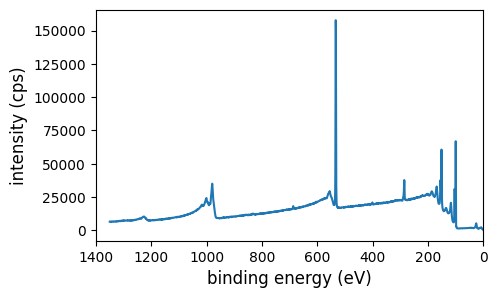

In [ ]:
import matplotlib.pyplot as plt

plt.figure( figsize=(5,3) )
plt.plot( wide_scan['energy'], wide_scan['intensity'] )
plt.xlim( 1400, 0 )  # xmin = 1400, xmax = 0
plt.xlabel( 'binding energy (eV)', fontsize='large' )
plt.ylabel( 'intensity (cps)', fontsize='large' )
plt.show()


The plot shows bands at various binding energies, each representing a well-populated electronic state. Our first task is to identify the energy of each state, and to do so programmatically rather than by visual inspection. To detect peaks, you might think to just identify local maxima, by using NumPy functions to differentiate the spectrum and then find its roots. But this simple approach often fails on real-world, noisy signals; because each small fluctuation is a local maximum but isn't actually a peak. Human perception of peaks relies on a variety of subtle criteria (peak height, peak width, peak symmetry, slope of inflection points, etc).

Accounting for these factors requires a more complex, sophisticated algorithm; fortunately this is a solved problem.

## SciPy function for peak detection

An exploratory search for "numpy identify peaks" or "algorithm to detect peaks despite noise" points us to the SciPy library. Its module `scipy.signal` includes a function named `find_peaks`. According to its [documentation page](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html), only the first argument `x` is required, and needs to be a sequence representing a signal. A Pandas Series is "array-like", so it counts as a sequence-type object.

The function returns *two* objects in a tuple: a NumPy array containing the indices of identified peaks within `x`, and a dictionary of various metrics for each peak. The code samples in the documentation show that you can capture these two return values using the syntax `peaks, properties = find_peaks( ... )`.

Try out the function with the intensity data in the DataFrame. Since it returns an array of peak indices, we can use it as an input to the DataFrame `loc[]` method, which selects the desired rows by index and creates a new DataFrame of these rows.

In [ ]:
import scipy.signal

intensity = wide_scan['intensity']
peak_indices, peak_properties = scipy.signal.find_peaks( intensity )
peaks = wide_scan.loc[ peak_indices ]
print( peaks.head() )

    energy  intensity
2   1349.0  6470.9445
8   1346.0  6556.1015
13  1343.5  6567.3012
16  1342.0  6575.0547
20  1340.0  6630.2577


To visualize the detected peaks, add a scatter plot of these points to the original line plot. The scatter plot will overlay circular markers on top of the spectrum at the top of each detected peak.

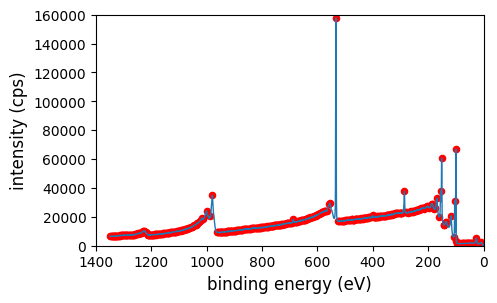

In [ ]:
import scipy.signal
import matplotlib.pyplot as plt

intensity = wide_scan['intensity']
peak_indices, peak_properties = scipy.signal.find_peaks( intensity )
peaks = wide_scan.loc[ peak_indices ]

plt.figure( figsize=(5,3) )
plt.plot( wide_scan['energy'], wide_scan['intensity'], lw=1 )
plt.scatter( peaks['energy'], peaks['intensity'], color='red', s=20 )
plt.axis( ( 1400, 0, 0, 160000) )
plt.xlabel( 'binding energy (eV)', fontsize='large' )
plt.ylabel( 'intensity (cps)', fontsize='large' )
plt.show()

Why does it show so many false peaks? As we suspected above, the default peak-finding algorithm is probably sensitive to noise. To check if this is the case, plot the spectrum between 900 eV and 800 eV, and between 10000 and 13000 cps, to effectivley zoom in on what is otherwise baseline signal. All of those little spikes should *not* count as peaks!


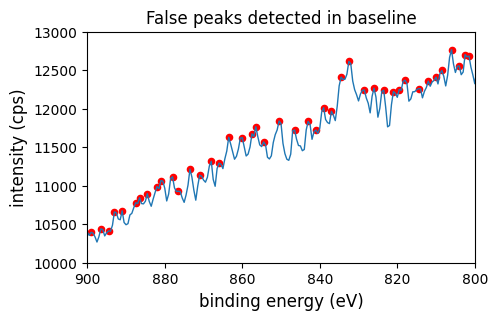

In [ ]:
plt.figure( figsize=(5,3) )
plt.plot( wide_scan['energy'], wide_scan['intensity'], lw=1 )
plt.scatter( peaks['energy'], peaks['intensity'], color='red', s=20 )
plt.axis( ( 900, 800, 10_000, 13_000) )  # zoom in
plt.xlabel( 'binding energy (eV)', fontsize='large' )
plt.ylabel( 'intensity (cps)', fontsize='large' )
plt.title( 'False peaks detected in baseline' )
plt.show()

Go back to the `find_peaks` [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html). The second paragraph of the docstring indicates the default behavior, which is very sensitive to noise:

> This function takes a 1-D array and **finds all local maxima by simple comparison of neighboring values**. Optionally, a subset of these peaks can be selected by specifying conditions for a peak's properties.

But it also notes that other options are available, presumably by setting keyword arguments:

- `height` specifies the minimum value that a signal value must have to count as a peak.
- `threshold` also specifies a minimum value, but is relative to *neighboring points*.
- `distance` specifies the minimum separation needed between suspected peak centers before they can be considered as peaks
- `prominence` specifies the required "prominence" of a suspected peak.

The docstring doesn't define prominence or describe what it means. The sample usage in that page points to another function `peak_prominences` (also in `scipy.signal.`), whose [documentation page](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.peak_prominences.html#peak-prominences) references the Wikipedia article on "[topographic prominence](https://en.wikipedia.org/wiki/Topographic_prominence)" and describes it as:

> ... how much a peak stands out from the surrounding baseline of the signal and is defined as the vertical distance between the peak and its lowest contour line ...

From visual inspection of the spectrum, and experience with XPS spectra, we know that absolute peak height varies quite a bit among identifiable peaks, so it will not be useful criterion to identify legitimate peaks. And given the noise in the spectrum, `threshold` won't be much help either. But `prominence` seems promising: it's based on peak height *relative to the local baseline*.

The smallest peaks appear to be a few thousand cps above the baseline. We can try to reason out the precise value, but it may be faster to simply try some values until the results match our human intuition. With prominence set to 500 cps, `find_peaks` seems to detect several false peaks in the baseline; at 2000 cps it seems to miss some of the smaller peaks. 1000 cps appears to be an ideal medium.

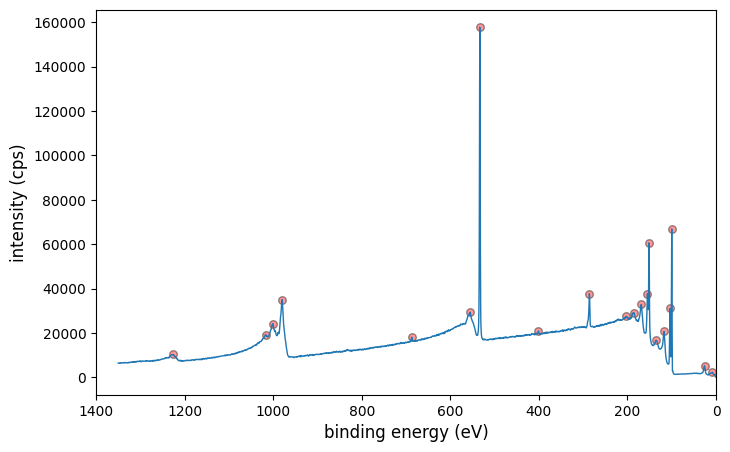

In [ ]:
intensity = wide_scan['intensity']
peak_indices, peak_properties = scipy.signal.find_peaks(
    intensity, prominence=1000
)
peaks = wide_scan.loc[ peak_indices ]

plt.figure( figsize=(8,5) )
plt.plot( wide_scan['energy'], wide_scan['intensity'], lw=1 )
plt.scatter(
    peaks['energy'], peaks['intensity'],
    color='red', alpha=0.4, s=30, lw=1, edgecolor='black'
)
plt.xlim( 1400, 0 )
plt.xlabel( 'binding energy (eV)', fontsize='large' )
plt.ylabel( 'intensity (cps)', fontsize='large' )
plt.show()

To assign peaks, print or display the DataFrame `peaks` and match (by inspection) the detected peak energies with literature values derived from XPS studies on reference samples; ThermoFisher Scientific have collected a reference table at their [Materials Science Learning Center](https://www.thermofisher.com/us/en/home/materials-science/learning-center/periodic-table.html). For example, Si 2p states are 99.4 eV in pure Si, so we should identify row 2500 in `peaks` as a "Si 2p" peak, and store this information in a new DataFrame named `assigned_peaks`. In contrast, C 1s states are 284.8 eV in diamond, which corresponds to row 2128. On Si/SiO<sub>2</sub> samples, we of course expect Si and O, but we should also C and N from surface contamination.

Create a DataFrame containing peak data for just these four elements.

In [ ]:
assigned_indices = [ 2500, 2128, 1898, 1633 ]
assigned_labels = [ "Si 2p","C 1s","N 1s","O 1s" ]

assigned_peaks = peaks.loc[ assigned_indices ]
assigned_peaks[ 'label' ] = assigned_labels

print( assigned_peaks )

      energy  intensity  label
2500   100.0   66897.22  Si 2p
2128   286.0   37744.80   C 1s
1898   401.0   20934.13   N 1s
1633   533.5  157753.33   O 1s


Then use these data to annotate the spectrum with text labels above the assigned peaks.

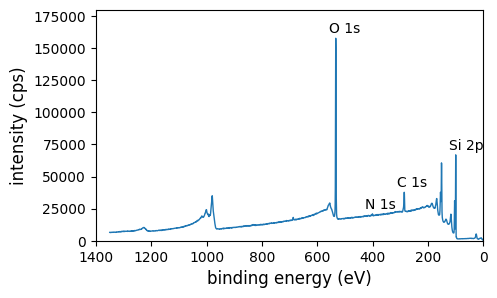

In [ ]:
import matplotlib.pyplot as plt
plt.figure( figsize=(5,3) )
plt.plot( wide_scan['energy'], wide_scan['intensity'], lw=1 )
for index in assigned_indices:
    row = assigned_peaks.loc[ index ]
    plt.annotate( row['label'], xy=( row['energy']+25, row['intensity']+4_000) )
plt.axis( ( 1400, 0, 0, 180_000) )
plt.xlabel( 'binding energy (eV)', fontsize='large' )
plt.ylabel( 'intensity (cps)', fontsize='large' )
plt.show()

## Summarize wide-scan analysis

Many of the scripts we ran above were exploratory, meant to help us understand the data set or the behavior of a function. Consolidate your code into a single script, meant to be run by a colleague who is just interested in the final result, i.e., a plot with annotated peaks and a table showing the precise data for each peak.

      energy  intensity  label
2500   100.0   66897.22  Si 2p
2128   286.0   37744.80   C 1s
1898   401.0   20934.13   N 1s
1633   533.5  157753.33   O 1s


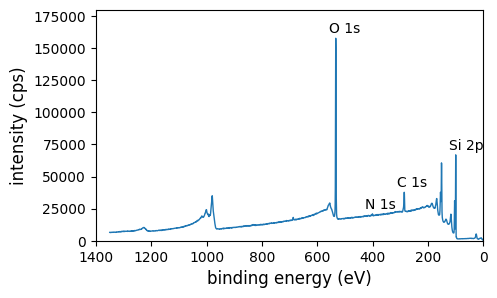

In [ ]:
import pandas as pd
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

wide_scan = pd.read_csv(
    'xpsdata/N0125701.asc', sep='\t',
    header=None, names=( 'energy', 'intensity')
)  # energy in eV, intensity in cps

intensity = wide_scan['intensity']
peak_indices, peak_properties = scipy.signal.find_peaks(
    intensity, prominence=1000
)
peaks = wide_scan.loc[ peak_indices ]

assigned_indices = [ 2500, 2128, 1898, 1633 ]
assigned_labels = [ "Si 2p","C 1s","N 1s","O 1s" ]
assigned_peaks = peaks.loc[ assigned_indices ]
assigned_peaks[ 'label' ] = assigned_labels

print( assigned_peaks )

plt.figure( figsize=(5,3) )
plt.plot( wide_scan['energy'], wide_scan['intensity'], lw=1 )
for index in assigned_indices:
    row = assigned_peaks.loc[ index ]
    plt.annotate( row['label'], xy=( row['energy']+25, row['intensity']+4_000) )
plt.axis( ( 1400, 0, 0, 180_000) )
plt.xlabel( 'binding energy (eV)', fontsize='large' )
plt.ylabel( 'intensity (cps)', fontsize='large' )
plt.show()

# Analyze high-resolution Si 2p XPS signal

## Import high-resolution data for Si 2p bands

The experimenters were interested in the chemical state of Si atoms at the oxidized surface. Although Si 2p orbitals are core levels, they are still sensitive to bond formation with different atoms; thus the binding energy shifts by about 4 eV in silicon dioxide. They followed up their wide-scan XPS experiment with a high-resolution scan of just the Si 2p region, recorded in the file "N0125702.asc".

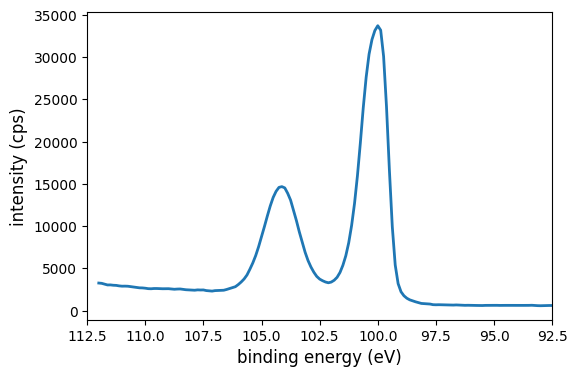

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal

silicon = pd.read_csv(
    'xpsdata/N0125702.asc', sep='\t',
    header=None, names=( 'energy', 'intensity')
)

plt.figure( figsize=(6,4) )
plt.plot( silicon['energy'], silicon['intensity'], lw=2 )
plt.xlim( 112.5, 92.5 )
plt.xlabel( 'binding energy (eV)', fontsize='large' )
plt.ylabel( 'intensity (cps)', fontsize='large' )
plt.show()


## Background correction

A typical goal of high-resolution XPS analysis is to measure the area under the curve (AUC) of a signal, because it is proportional to the concentration of atoms associated with the signal. But currently the spectrum's baseline is not zero, which will surely interefere with accurate measurement of AUC unless removed. A typical approach to background removal is to define a polynomial function that best fits the baseline and then subtract it point by point from the spectrum. NumPy provides two functions to help with this task.

The function `polyval` takes an array of polynomial coefficients starting with the highest power, e.g. [ *c<sub>n</sub>*, *c<sub>n-1</sub>*, ..., *c<sub>0</sub>* ], along with an array of *x* values, and computes the corresponding polynomial function for each *x* value, e.g. *f(x)* = *c<sub>n</sub>* • *x<sup>n</sup>* + *c<sub>n-1</sub>* • *x<sup>n-1</sup>* + ... + *c<sub>0</sub>* • *x<sup>0</sup>*. [According to its documentation](https://numpy.org/doc/2.0/reference/generated/numpy.polyval.html), the function infers the polynomial degree from the length of the coefficient array (though it explains this in a fairly confusing way).

Conversely, the function `polyfit` takes arrays of *x* and *y* values, along with a specified polynomial degree *n*, and finds a set of *n* + 1 coefficients for a polynomial function that best fits *y(x)*. [According to the function's documentation](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html), it will return an array of coefficient values starting with the highest power, e.g. [ *c<sub>n</sub>*, *c<sub>n-1</sub>*, ..., *c<sub>0</sub>* ]. This ordering matches how `polyval` interprets a given coefficient array.

The program below starts by fitting the specturm with a degree 1 polynomial model (i.e., a linear function), generates an array to represent the background, and plots it over the spectrum for comparison. It's immediately apparent that the modeled background is higher than the baseline, probably because the non-baseline, peak values were included in the fit, thus "pulling up" the result.

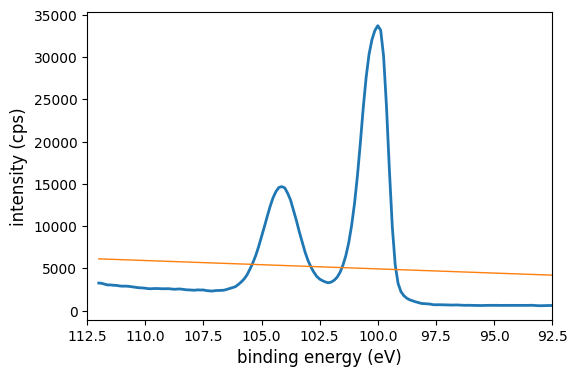

In [ ]:
import numpy as np

coeffs = np.polyfit( silicon['energy'], silicon['intensity'], 1)
background = np.polyval( coeffs, silicon['energy'] )

plt.figure( figsize=(6,4) )
plt.plot( silicon['energy'], silicon['intensity'], lw=2 )
plt.plot( silicon['energy'], background, lw=1 )
plt.xlim( 112.5, 92.5 )
plt.xlabel( 'binding energy (eV)', fontsize='large' )
plt.ylabel( 'intensity (cps)', fontsize='large' )
plt.show()


To remove non-baseline values from the fit, create a masking array to exclude values from 107 eV to 98 eV; then use it to select the corresponding rows from the DataFrame.

With this change, the modeled background mostly lines up with the perceived baseline; but it's clear that the baseline has some curvature that the 1st-order linear model cannot follow. Try different polynomial degrees; 3 seems to be good enough for this spectrum.

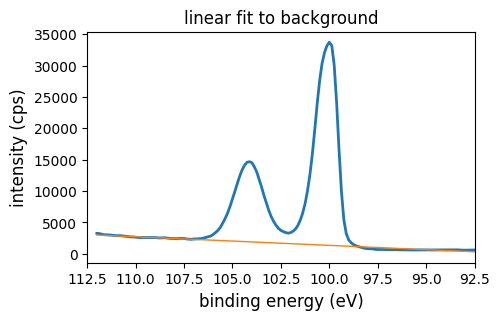

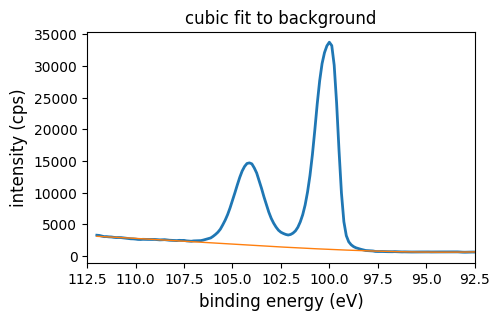

In [ ]:
import numpy as np

baseline_mask = (silicon['energy'] < 98) | (silicon['energy'] > 107)
baseline = silicon.loc[ baseline_mask ]

# Fit with order 1 polynomial
coeffs = np.polyfit( baseline['energy'], baseline['intensity'], 1 )
background = np.polyval( coeffs, silicon['energy'] )

plt.figure( figsize=(5,3) )
plt.plot( silicon['energy'], silicon['intensity'], lw=2 )
plt.plot( silicon['energy'], background, lw=1 )
plt.xlim( 112.5, 92.5 )
plt.xlabel( 'binding energy (eV)', fontsize='large' )
plt.ylabel( 'intensity (cps)', fontsize='large' )
plt.title ( 'linear fit to background' )
plt.show()

# Fit with order 3 polynomial
coeffs = np.polyfit( baseline['energy'], baseline['intensity'], 3 )
background = np.polyval( coeffs, silicon['energy'] )

plt.figure( figsize=(5,3) )
plt.plot( silicon['energy'], silicon['intensity'], lw=2 )
plt.plot( silicon['energy'], background, lw=1 )
plt.xlim( 112.5, 92.5 )
plt.xlabel( 'binding energy (eV)', fontsize='large' )
plt.ylabel( 'intensity (cps)', fontsize='large' )
plt.title ( 'cubic fit to background' )
plt.show()

Once the background is established, subtract it point-for-point from the XPS spectrum to correct it.

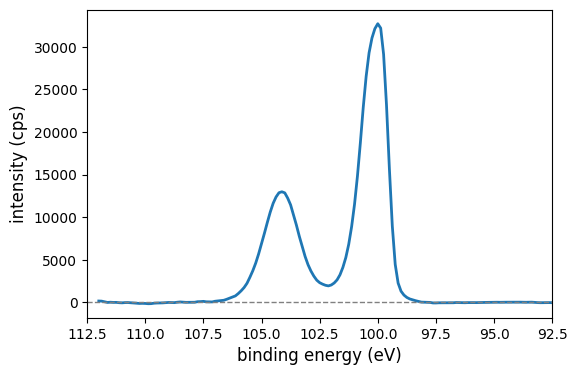

In [ ]:
import numpy as np

baseline_mask = (silicon['energy'] < 98) | (silicon['energy'] > 107)
baseline = silicon.loc[ baseline_mask ]

coeffs = np.polyfit( baseline['energy'], baseline['intensity'], 3 )
background = np.polyval( coeffs, silicon['energy'] )

silicon_corrected = silicon['intensity'] - background

plt.figure( figsize=(6,4) )
plt.plot( silicon['energy'], silicon_corrected, lw=2 )
plt.hlines( 0, 112.5, 92.5, linestyle='--', lw=1, color='gray' )
plt.xlim( 112.5, 92.5 )
plt.xlabel( 'binding energy (eV)', fontsize='large' )
plt.ylabel( 'intensity (cps)', fontsize='large' )
plt.show()

## Find area through numerical integration

If the "left" peak at ~104 eV arises from oxidized silicon atoms, and the "right" peak at ~99 eV arises from elemental silicon atoms, then their relative areas (AUCs) should reflect the relative concentration of each type of Si. We can use the NumPy function `trapezoid` to find this area through [numerical integration](https://openstax.org/books/calculus-volume-2/pages/3-6-numerical-integration).

[According to its documentation](https://numpy.org/doc/stable/reference/generated/numpy.trapezoid.html#numpy-trapezoid), `trapezoid` takes *x* and *y* arrays as arguments, but its API does not include arguments to specify the starting and ending points of the integration. This means we need to select subsets of the signal to represent as the left peak (energy >= 102.125 eV) and right peak (energy < 102.125). Create masking arrays and use them to select different parts of the DataFrame `silicon` to integate.

Check the order of arguments carefully! The `trapezoid` documentation shows that the *y* values (in this case the corrected intensity) should be the first argument, followed by the *x* values (binding energy).

In [ ]:
import numpy as np

left_mask = silicon['energy'] >= 102.125
right_mask = silicon['energy'] < 102.125

left_silicon = silicon.loc[ left_mask ]
right_silicon = silicon.loc[ right_mask ]

left_area  = -np.trapezoid( left_silicon['corrected'],  left_silicon['energy']  )
right_area = -np.trapezoid( right_silicon['corrected'], right_silicon['energy'] )
total_area = left_area + right_area

print( f'left peak area: {left_area:.5g} ({left_area/total_area*100:.3g}%)' )
print( f'right peak area: {right_area:.5g} ({right_area/total_area*100:.3g}%)' )

left peak area: 26055 (35.8%)
right peak area: 46708 (64.2%)


## Save results

Export the background-corrected data set to a CSV file, so that you can share this "cleaned" data set with other researchers (or your future self). But don't simply export the corrected intensities without context. Instead add them as a new column to the original DataFrame; that way they will be matched with binding energies, but also with the uncorrected signal in case someone (or again, your future self) needs to check or replicate your analysis.

In [ ]:
silicon['corrected'] = silicon_corrected
silicon.to_csv( 'si-2p-corrected.csv', index=False )

Actually, it might be a good idea to review your exploratory code above, and consolidate it into a single script that a colleague (or, at the risk of sounding repetitive, your future self) can examine.

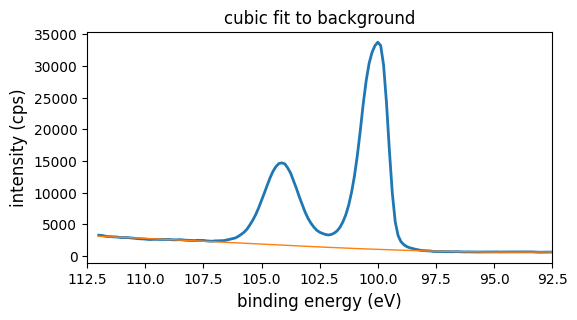

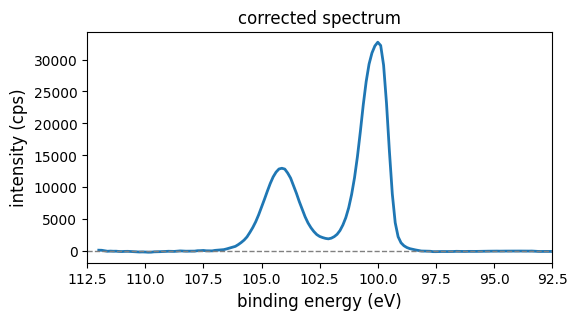

left peak area: 26055 (35.8%)
right peak area: 46708 (64.2%)


In [ ]:
# Analyze hi-res XPS spectrum of Si 2p region

import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal
import numpy as np

silicon = pd.read_csv(
    'xpsdata/N0125702.asc', sep='\t',
    header=None, names=( 'energy', 'intensity')
)  # energy in eV, intensity in cps

# Define a mask to exclude region 98 eV - 107 eV from baseline correciton
baseline_mask = (silicon['energy'] < 98) | (silicon['energy'] > 107)
baseline = silicon.loc[ baseline_mask ]

# Fit degree-3 polynomial to just the baseline data
coeffs = np.polyfit( baseline['energy'], baseline['intensity'], 3 )
background = np.polyval( coeffs, silicon['energy'] )

# Confirm visually that background matches baseline reasonably
plt.figure( figsize=(6,3) )
plt.plot( silicon['energy'], silicon['intensity'], lw=2 )
plt.plot( silicon['energy'], background, lw=1 )
plt.xlim( 112.5, 92.5 )
plt.xlabel( 'binding energy (eV)', fontsize='large' )
plt.ylabel( 'intensity (cps)', fontsize='large' )
plt.title ( 'cubic fit to background' )
plt.show()

# Subtract background from signal, store as new column 'corrected', and save
silicon['corrected'] = silicon['intensity'] - background
silicon.to_csv( 'si-2p-corrected.csv', index=False )

plt.figure( figsize=(6,3) )
plt.plot( silicon['energy'], silicon['corrected'], lw=2 )
plt.hlines( 0, 112.5, 92.5, linestyle='--', lw=1, color='gray' )
plt.xlim( 112.5, 92.5 )
plt.xlabel( 'binding energy (eV)', fontsize='large' )
plt.ylabel( 'intensity (cps)', fontsize='large' )
plt.title ( 'corrected spectrum' )
plt.show()

# Add corrected intensities to dataframe and export
silicon.to_csv( 'si-2p-corrected.csv', index=False )

# Calculate area under curve of each peak
left_mask = silicon['energy'] >= 102.125
right_mask = silicon['energy'] < 102.125
left_silicon = silicon.loc[ left_mask ]
right_silicon = silicon.loc[ right_mask ]

left_area  = -np.trapezoid( left_silicon['corrected'],  left_silicon['energy']  )
right_area = -np.trapezoid( right_silicon['corrected'], right_silicon['energy'] )
total_area = left_area + right_area

print( f'left peak area: {left_area:.5g} ({left_area/total_area*100:.3g}%)' )
print( f'right peak area: {right_area:.5g} ({right_area/total_area*100:.3g}%)' )

# Numerical modelling of peaks

Overlap of multiple peaks can lead to apparent distortions in actual peak center and shape. A common practice in XPS analysis is to create a numerical model of multiple, overlapping peaks, and fit it to the (background-corrected) spectrum to obtain a separate set of coefficients for each peak. If successful, this type of analysis can lead to additional insights into the surface state; and more precise accurate analysis of peak areas.

To model a single peak, we need a function that produces a "peak-like" shape, such as a [Gaussian](https://en.wikipedia.org/wiki/Gaussian_function), [Lorentzian](https://en.wikipedia.org/wiki/Cauchy_distribution), or [Voigt](https://en.wikipedia.org/wiki/Cauchy_distribution) function. For covalent compounds like silicon and silicon dioxide, XPS peaks tend to have a Gaussian lineshape. [[1]](#JVST)

$$ y(x) = a_1 \exp\left[-\frac{1}{2}\left(\frac{x - b_1}{c_1}\right)^2\right] $$

The equation for a Gaussian function has three parameters, and each one determines a different aspect of a peak's shape:

- $a_1$: maximum height of the peak
- $b_1$: center position (*x* where peak is at maximum)
- $c_1$: width of the peak (distance from peak to each inflection point)

Why add the subscript "1" to each coefficient? We anticipate adding multiple peaks -- and thus multiple sets of parameters -- to our model later!

<a name="JVST">[1]</a> George H. Major, Neal Fairley, Peter M. A. Sherwood, Matthew R. Linford, Jeff Terry, Vincent Fernandez, Kateryna Artyushkova; Practical guide for curve fitting in x-ray photoelectron spectroscopy. J. Vac. Sci. Technol. A 1 December 2020; 38 (6): 061203. https://doi.org/10.1116/6.0000377

## Gaussian model of a single peak

Define a Python function that computes the Gaussian function given x and values for the three parameters. To test it, assume a Gaussian curve with a height of 10, centered at 0, and with a width of 1, and then call it for a few values of *x*. For *x*=0, we know already that *f*(0) should return 10.0; compute *f*(1) and *f*(2) by hand and check the output of the function. Also check that when the center is set to a different value, such as *b1*=5, then *f*(5) should still return the maximum height.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

def gaussian( x, a1, b1, c1 ):
    exponent = - 1/2 * ( (x - b1) / c1 ) ** 2
    return a1 * math.exp( exponent )

print( gaussian( 0, 10, 0, 1 ) )  ## height 10, centered at 0, f(0) = 10.0
print( gaussian( 1, 10, 0, 1 ) )  ## height 10, centered at 0, f(1) = 6.07
print( gaussian( 2, 10, 0, 1 ) )  ## height 10, centered at 0, f(2) = 1.35
print( gaussian( 5, 10, 5, 1 ) )  ## height 10, centered at 1, f(5) = 10.0

10.0
6.065306597126334
1.353352832366127
10.0


Now test the function on an entire array of *x* values, specifically the energies from the high-resolution scan of the Si peaks. Use more realistic parameter values, such as a height of 10,000 cps, peak center of 105 eV, and a peak width of 1 eV; and call the function on `silicon['energy']` from the previously processed data set.

Our initial attempt should raise `TypeError: cannot convert the series to <class 'float'>`, because `math.exp` is not defined for array types. Use the NumPy version of `exp` to vectorize the function implicitly (or use `@np.vectorize` to do so explicitly.)

Plot the experimental spectrum using markers, and overlay a plot of the simulated spectrum for comparison.

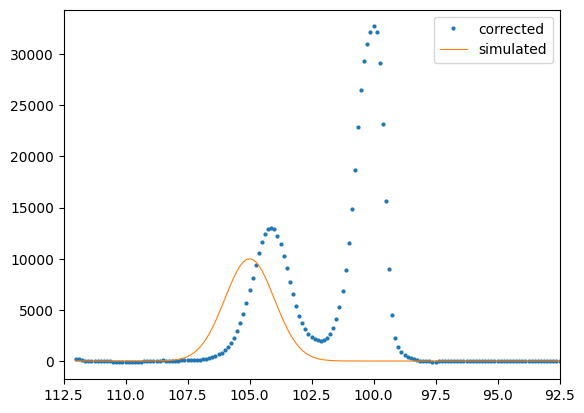

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian( x, a1, b1, c1 ):
    exponent = - 1/2 * ( (x - b1) / c1 ) ** 2
    return a1 * np.exp( exponent )

energy = silicon['energy']
simulated = gaussian( energy, 10_000, 105, 1 )

plt.plot( silicon['energy'], silicon['corrected'], 'o', ms=2, label='corrected' )
plt.plot( silicon['energy'], simulated, lw=0.8, label='simulated' )
plt.xlim( 112.5, 92.5 )
plt.legend()
plt.show()

Change the parameter values for the simulation to `a1=12_000`, `b1=104`, `c1=0.5`; and run the program again to observe that the simulated peak better matches the left-hand peak. Adjust and "fine-tune" these parameter values repeatedly until the simulated curve matches the left-hand peak. The final values should be approximately `a1=12_800`, `b1=104.15`, `c1=0.75`.


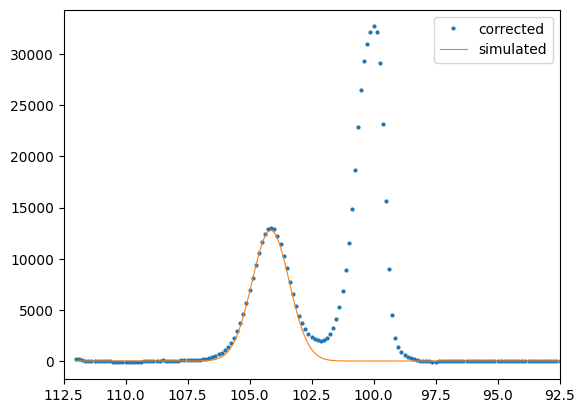

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian( x, a1, b1, c1 ):
    exponent = - 1/2 * ( (x - b1) / c1 ) ** 2
    return a1 * np.exp( exponent )

( a1, b1, c1 )  = ( 12_800, 104.15, 0.75 )

energy = silicon['energy']
simulated = gaussian( energy, a1, b1, c1 )

plt.plot( silicon['energy'], silicon['corrected'], 'o', ms=2, label='corrected' )
plt.plot( silicon['energy'], simulated, lw=0.8, label='simulated' )
plt.xlim( 112.5, 92.5 )
plt.legend()
plt.show()

As an exercise, find the parameter values that would resemble the other peak on the right. They should be close to `a1=32_200`, `b1=100.18`, `c1=0.60`.

## Composite gaussian model of XPS signal

To simulate a two-peak spectrum, define a new function `double_gaussian` that takes a value for *x* along with *six* other parameters; and computes the sum of two independent gaussian functions. Adjust the six parameter values until the simulated spectrum matches both peaks simultaneously.

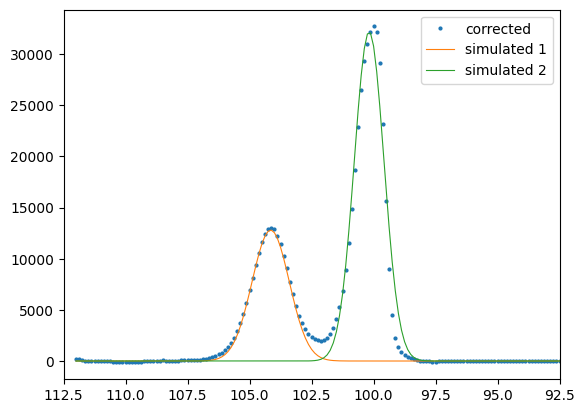

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian( x, a1, b1, c1 ):
    exponent = - 1/2 * ( (x - b1) / c1 ) ** 2
    return a1 * np.exp( exponent )

def double_gaussian( x, a1, b1, c1, a2, b2, c2 ):
    return gaussian( x, a1, b1, c1 ) + gaussian( x, a2, b2, c2 )


( a1, b1, c1 )  = ( 12_800, 104.15, 0.75 )
( a2, b2, c2 )  = ( 32_200, 100.18, 0.60 )

energy = silicon['energy']
simulated1 = gaussian( energy, a1, b1, c1 )
simulated2 = gaussian( energy, a2, b2, c2 )

plt.plot( silicon['energy'], silicon['corrected'], 'o', ms=2, label='corrected' )
plt.plot( silicon['energy'], simulated1, lw=0.8, label='simulated 1' )
plt.plot( silicon['energy'], simulated2, lw=0.8, label='simulated 2' )
plt.xlim( 112.5, 92.5 )
plt.legend()
plt.show()

This approach to adjusting parameters can be automated using `curve_fit` from the module `scipy.optimize`. The interface of this function is complex, so [study its documentation carefully](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html) to understand its arguments and return values.

*Optional:* To get the estimated uncertainty of each parameter, use the diagonal elements of the covariance matrix:

```python
    ( a1s, b1s, c1s, a2s, b2s, c2s, ) = np.sqrt( np.diag( covariance ) )
```

Peak 1: height: 12599; center: 104.12; width: 0.82623
Peak 2: height: 33422; center: 100.17; width: 0.5494


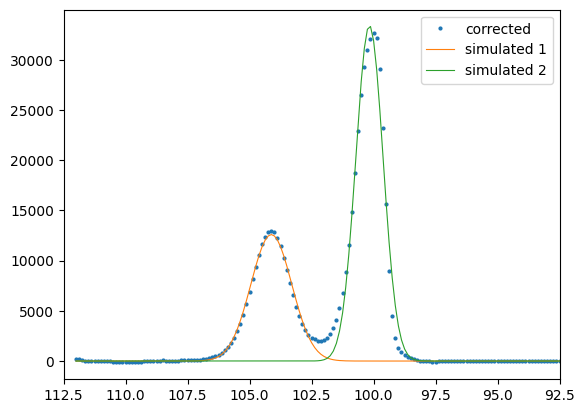

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def gaussian( x, a1, b1, c1 ):
    exponent = - 1/2 * ( (x - b1) / c1 ) ** 2
    return a1 * np.exp( exponent )

def double_gaussian( x, a1, b1, c1, a2, b2, c2 ):
    return gaussian( x, a1, b1, c1 ) + gaussian( x, a2, b2, c2 )

# Initial guesses for parameter values
( a1, b1, c1 )  = ( 12_800, 104.15, 0.75 )
( a2, b2, c2 )  = ( 32_200, 100.18, 0.60 )

parameters, covariance = curve_fit(
    double_gaussian, silicon['energy'], silicon['corrected'],
    p0=(a1, b1, c1, a2, b2, c2)
)

( a1, b1, c1, a2, b2, c2, ) = parameters

print(f'Peak 1: height: {a1:.5g}; center: {b1:.5g}; width: {c1:.5g}')
print(f'Peak 2: height: {a2:.5g}; center: {b2:.5g}; width: {c2:.5g}')

energy = silicon['energy']
simulated1 = gaussian( energy, a1, b1, c1 )
simulated2 = gaussian( energy, a2, b2, c2 )

plt.plot( silicon['energy'], silicon['corrected'], 'o', ms=2, label='corrected' )
plt.plot( silicon['energy'], simulated1, lw=0.8, label='simulated 1' )
plt.plot( silicon['energy'], simulated2, lw=0.8, label='simulated 2' )
plt.xlim( 112.5, 92.5 )
plt.legend()
plt.show()

The area under a Gaussian function is $\sqrt{2\pi} a c$. If the best-fit parameter values are representative of a peak's shape, then you can estimate peak areas directly from these values. Compare this approach with numerical integation: for the left peak it matches the earlier results pretty well, but for the right peak it underestimates by about 700 eV•cps (-2%).

In [ ]:
area1 = np.sqrt( 2 * np.pi ) * a1 * c1
area2 = np.sqrt( 2 * np.pi ) * a2 * c2
total = area1 + area2

print( f'peak 1 area: {area1:.5g} ({area1/total*100:.3g}%)')
print( f'peak 2 area: {area2:.5g} ({area2/total*100:.3g}%)')

peak 1 area: 26093 (36.2%)
peak 2 area: 46027 (63.8%)


## Even more peaks

There are two reasons you may find the two-peak fit unsatisfying:

- The right hand peak is asymmetrical. Compared to the simulated Gaussian, it appears to be centered slightly to the right (lower energy), but with a "shoulder" that pulls the best-fit to the left.
- Between 102.5 eV to 101.0 eV, the signal shows significant intensity (~2000 cps), that the combined simulated peaks fail do not account for.

To make these deficiencies more obvious, zoom in on just the peak region and lengthen the figure size.

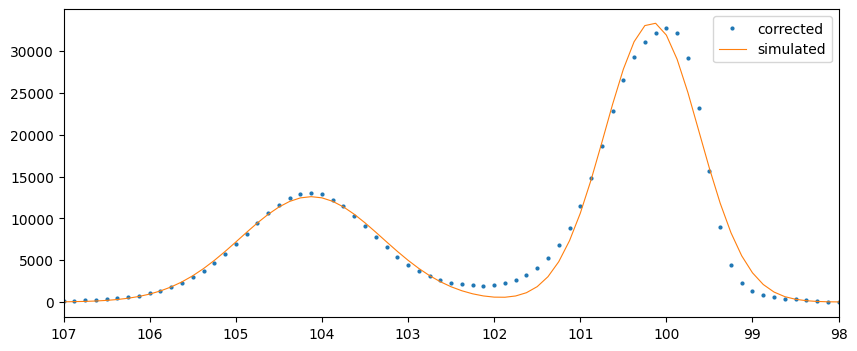

In [ ]:
plt.figure( figsize=(10,4) )
plt.plot( silicon['energy'], silicon['corrected'], 'o', ms=2, label='corrected' )
plt.plot( silicon['energy'], simulated1 + simulated2, lw=0.8, label='simulated' )
plt.xlim( 107, 98 )
plt.legend()
plt.show()

An asymmetric peak is often a sign that there may be another peak "buried" in it, with a different height, center, and width. In addition, the region of unaccounted intesity between the two main peaks may indicate another hidden peak, this one shorter and broader. These peaks could correspond to other states of silicon, probably with intermediate oxidation state between 0 and +4.

### ✍ Exercise

Extend the two-peak analysis and fit a four-peak model to the spectrum.

### 💡 Sample solution

Assumes DataFrame `silicon` has already been imported, and contains column `corrected` for background-corrected signal.

Includes some quality-of-life enhancements:

- Format Specification Mini-Language
    - the bit after the colon in an f-string
    - defined at [official Python documentation](https://docs.python.org/3/library/string.html#formatspec) for `string` type
    - but explained better at [PyFormat](https://pyformat.info/)
    - for example, `f'{number:7.1f}'` sets aside 7 characters total to represent the float `number`, but rounds to the first place after the decimal point.
- Parameter uncertainty
    - extracts square root of diagonal components of covariance matrix, to show the uncertainty (1 standard deviation) of each parameter estimate.
- Plot refinements
    - Axis labels
    - Each component simulation as a thin line
    - Composite simulation as a thick gray line
    - Experimental data as larger circles



Parameter Estimates:
Peak 1: height: 11438; center: 104.19; width: 0.69
Peak 2: height: 27188; center: 100.29; width: 0.50
Peak 3: height: 13318; center:  99.78; width: 0.25
Peak 4: height:  2149; center: 102.70; width: 2.02

Parameter Uncertainties:
Peak 1: height:   154; center:   0.01; width: 0.01
Peak 2: height:   475; center:   0.01; width: 0.01
Peak 3: height:   848; center:   0.00; width: 0.01
Peak 4: height:   107; center:   0.18; width: 0.10

Areas:
Peak 1 area: 19731 (27%)
Peak 2 area: 34275 (47%)
Peak 3 area:  8438 (12%)
Peak 4 area: 10878 (15%)


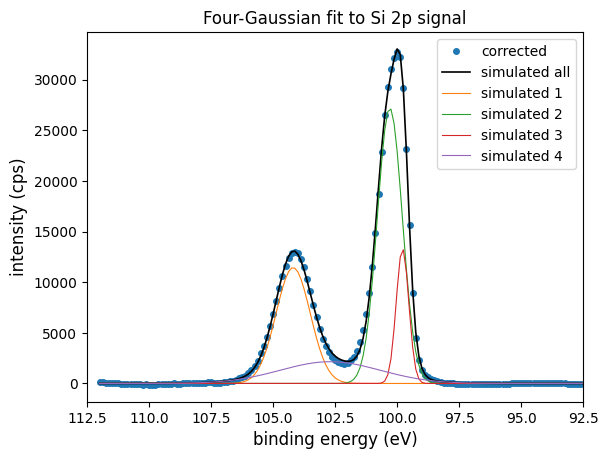

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def gaussian( x, a1, b1, c1 ):
    exponent = - 1/2 * ( (x - b1) / c1 ) ** 2
    return a1 * np.exp( exponent )

def quarto_gaussian( x, a1, b1, c1, a2, b2, c2, a3, b3, c3, a4, b4, c4 ):
    return gaussian( x, a1, b1, c1 ) + gaussian( x, a2, b2, c2 ) \
         + gaussian( x, a3, b3, c3 ) + gaussian( x, a4, b4, c4 )

( a1, b1, c1 )  = ( 12_800, 104.2, 0.7 )
( a2, b2, c2 )  = ( 32_800, 100.1, 0.5 )
( a3, b3, c3 )  = ( 15_000,  99.8, 0.5 )
( a4, b4, c4 )  = (  2_000, 101.0, 1.0 )

parameters, covariance = curve_fit(
    quarto_gaussian, silicon['energy'], silicon['corrected'],
    p0=(a1, b1, c1, a2, b2, c2, a3, b3, c3, a4, b4, c4)
)

( a1, b1, c1, a2, b2, c2, a3, b3, c3, a4, b4, c4 ) = parameters
( a1s, b1s, c1s, a2s, b2s, c2s, a3s, b3s, c3s, a4s, b4s, c4s ) = \
    np.sqrt( np.diag( covariance ) )

print()
print( 'Parameter Estimates:' )
print(f'Peak 1: height: {a1:5.0f}; center: {b1:6.2f}; width: {c1:4.2f}')
print(f'Peak 2: height: {a2:5.0f}; center: {b2:6.2f}; width: {c2:4.2f}')
print(f'Peak 3: height: {a3:5.0f}; center: {b3:6.2f}; width: {c3:4.2f}')
print(f'Peak 4: height: {a4:5.0f}; center: {b4:6.2f}; width: {c4:4.2f}')
print()
print( 'Parameter Uncertainties:' )
print(f'Peak 1: height: {a1s:5.0f}; center: {b1s:6.2f}; width: {c1s:4.2f}')
print(f'Peak 2: height: {a2s:5.0f}; center: {b2s:6.2f}; width: {c2s:4.2f}')
print(f'Peak 3: height: {a3s:5.0f}; center: {b3s:6.2f}; width: {c3s:4.2f}')
print(f'Peak 4: height: {a4s:5.0f}; center: {b4s:6.2f}; width: {c4s:4.2f}')

area1 = np.sqrt(2 * np.pi) * a1 * c1
area2 = np.sqrt(2 * np.pi) * a2 * c2
area3 = np.sqrt(2 * np.pi) * a3 * c3
area4 = np.sqrt(2 * np.pi) * a4 * c4
total = area1 + area2 + area3 + area4
print()
print( 'Areas:' )
print(f'Peak 1 area: {area1:5.0f} ({area1/total*100:2.0f}%)')
print(f'Peak 2 area: {area2:5.0f} ({area2/total*100:2.0f}%)')
print(f'Peak 3 area: {area3:5.0f} ({area3/total*100:2.0f}%)')
print(f'Peak 4 area: {area4:5.0f} ({area4/total*100:2.0f}%)')

energy = silicon['energy']
simulated1 = gaussian( energy, a1, b1, c1 )
simulated2 = gaussian( energy, a2, b2, c2 )
simulated3 = gaussian( energy, a3, b3, c3 )
simulated4 = gaussian( energy, a4, b4, c4 )

plt.plot( silicon['energy'], silicon['corrected'], 'o', ms=4,
          label='corrected' )
plt.plot(
    silicon['energy'], simulated1 + simulated2 + simulated3 + simulated4,
    lw=1.2, label='simulated all', c='black'
)
plt.plot( silicon['energy'], simulated1, lw=0.8, label='simulated 1' )
plt.plot( silicon['energy'], simulated2, lw=0.8, label='simulated 2' )
plt.plot( silicon['energy'], simulated3, lw=0.8, label='simulated 3' )
plt.plot( silicon['energy'], simulated4, lw=0.8, label='simulated 4' )
plt.xlim( 112.5, 92.5 )
plt.xlabel( 'binding energy (eV)', fontsize='large' )
plt.ylabel( 'intensity (cps)', fontsize='large' )
plt.title ( 'Four-Gaussian fit to Si 2p signal' )
plt.legend()
plt.show()